In [212]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import VotingRegressor

In [4]:
path = "raw_data/train.csv"
df = pd.read_csv(path)

In [5]:
df["gender"].unique()

array(['Male', 'Female', 'Non-binary'], dtype=object)

In [6]:
df.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [7]:
df["training_program"].value_counts()

training_program
Beginner        39983
Intermediate    25287
Advanced        14730
Name: count, dtype: int64

In [8]:
df["marathon_weather"].value_counts()

marathon_weather
Cloudy    20054
Sunny     20045
Rainy     11955
Hot       11921
Cold       8040
Windy      7985
Name: count, dtype: int64

In [9]:
df["course_difficulty"].value_counts()

course_difficulty
Flat     31849
Mixed    24178
Hilly    23973
Name: count, dtype: int64

In [10]:
df["injury_severity"].value_counts()

injury_severity
Minor       16958
Moderate     9909
Severe       5783
Name: count, dtype: int64

In [108]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       80000 non-null  object 
 1   age                             80000 non-null  int64  
 2   gender                          80000 non-null  object 
 3   running_experience_months       80000 non-null  int64  
 4   previous_marathon_count         80000 non-null  int64  
 5   training_program                80000 non-null  object 
 6   motivation_level                80000 non-null  int64  
 7   personal_best_minutes           69255 non-null  float64
 8   weekly_mileage_km               80000 non-null  float64
 9   weekly_mileage_miles            80000 non-null  float64
 10  runs_per_week                   80000 non-null  int64  
 11  long_run_distance_km            80000 non-null  float64
 12  speed_work_sessions_per_week    

In [12]:
df.describe()

,age,running_experience_months,previous_marathon_count,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,speed_work_sessions_per_week,...,early_morning_run_frequency,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
count,80000.000000,80000.000000,80000.000000,80000.000000,69255.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,78011.000000,80000.000000,80000.000000
mean,41.538412,36.147413,2.004700,5.505575,259.321580,29.940183,17.225917,4.356975,15.828567,0.978862,...,34.382600,29.235175,64.490900,40.010475,60.272625,52.179725,249.308687,287.931407,6.372187,0.450000
std,13.848164,35.453932,1.419094,2.871288,33.778153,17.392518,7.072490,0.896649,2.358518,0.645074,...,24.113435,21.936089,17.171607,28.388266,20.957232,24.647479,30.372115,33.648005,2.067061,0.804679
min,18.000000,6.000000,0.000000,1.000000,132.000000,20.000000,12.400000,3.000000,15.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,171.000000,1.000000,0.000000
25%,30.000000,10.000000,1.000000,3.000000,236.000000,20.000000,12.400000,4.000000,15.000000,1.000000,...,15.000000,11.000000,53.000000,16.000000,46.000000,35.000000,228.000000,265.000000,5.000000,0.000000
50%,42.000000,25.000000,2.000000,6.000000,261.000000,20.600000,12.400000,4.000000,15.000000,1.000000,...,33.000000,28.000000,65.000000,39.000000,61.000000,52.000000,252.000000,290.000000,7.000000,0.000000
75%,54.000000,49.000000,3.000000,8.000000,283.000000,34.300000,20.500000,5.000000,15.000000,1.000000,...,51.000000,45.000000,77.000000,61.000000,75.000000,70.000000,272.000000,313.000000,8.000000,1.000000
max,65.000000,240.000000,11.000000,10.000000,377.000000,119.994348,60.200000,7.000000,41.200000,3.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,350.000000,400.000000,10.000000,3.000000


In [123]:
df_prep = df.copy()

In [50]:
# Create is_finished
#df_prep['is_finished'] = df_prep['actual_finish_time_minutes'].notnull().astype(int)

In [124]:
# Remove rows where the target is missing
df_prep.dropna(subset=['actual_finish_time_minutes'], inplace=True)

In [125]:
# Ordinal maps for ranked categories
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map   = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map   = {"Minor": 1, "Moderate": 2, "Severe": 3}

In [126]:
# Mapping
df_prep['training_program_enc'] = df_prep['training_program'].map(training_map)
df_prep['course_difficulty_enc'] = df_prep['course_difficulty'].map(course_map)
df_prep['injury_severity_enc']   = df_prep['injury_severity'].map(injury_map).fillna(0)

In [127]:
# Binary encoding for gender and rookie status
df_prep['is_rookie'] = df_prep['personal_best_minutes'].isna().astype(int)

In [57]:
# Extract month from marathon date
#df_prep['marathon_month'] = pd.to_datetime(df_prep['marathon_date']).dt.month

In [128]:
# One-Hot Encoding for weather
df_prep = pd.get_dummies(df_prep, columns=['marathon_weather'])

In [129]:
# Smart imputation for VO2 Max based on age groups
df_prep['vo2_max'] = df_prep['vo2_max'].fillna(
    df_prep.groupby('age')['vo2_max'].transform('median')
)

In [130]:
# One-Hot Encoding for gender
df_prep = pd.get_dummies(df_prep, columns=['gender'])

In [131]:
# Fill remaining numerical columns with median
cols_to_fix = [
    'cross_training_hours_per_week', 'sleep_hours_avg',
    'nutrition_score', 'hydration_consistency'
]

In [132]:
for col in cols_to_fix:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

In [136]:
# Columns to remove
drop_list = [
    "runner_id", "weekly_mileage_miles", "target_finish_time_minutes",
    "medal_outcome", "marathon_date", "training_program",
    "course_difficulty", "injury_severity", "personal_best_minutes"]

In [137]:
# Final numeric-only dataframe
df_final = df_prep.drop(columns=drop_list)

## Correlation

<Axes: ylabel='None'>

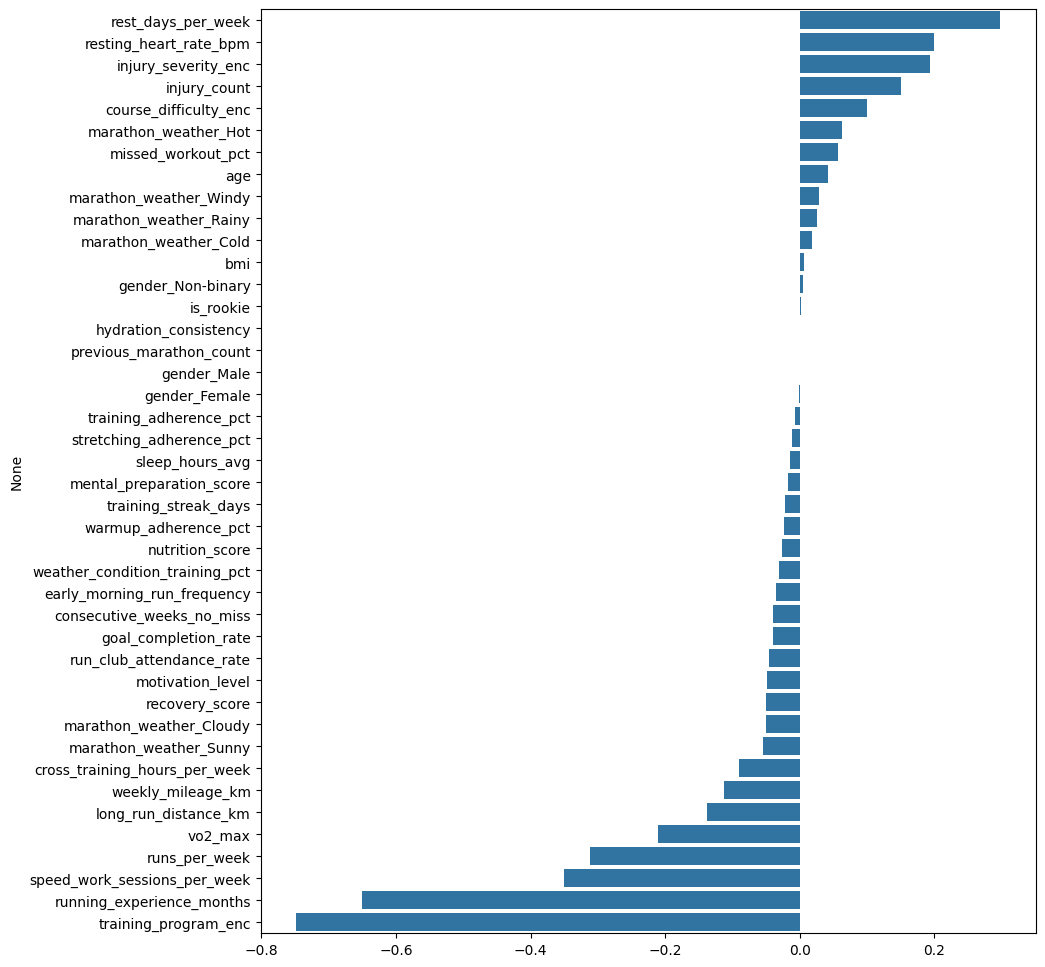

In [139]:
correlations = df_final.corr()['actual_finish_time_minutes'].sort_values(ascending=False)
correlations = correlations.drop('actual_finish_time_minutes')
plt.figure(figsize=(10, 12))
sns.barplot(x=correlations.values, y=correlations.index)

## Model Training

In [157]:
X = df_final.drop(columns=['actual_finish_time_minutes'])
y = df_final['actual_finish_time_minutes']

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [141]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [142]:
# Evaluate the model
y_pred = model.predict(X_test)

In [143]:
print(f"Baseline R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test, y_pred):.2f} minutes")

Baseline R2 Score: 0.6349
Baseline MAE: 16.12 minutes


## Experiment

In [152]:
df_experminet = df_final.copy()

### Removing non-imporatant Features

In [154]:
df_experminet.drop(columns=remove_list, inplace=True)

In [146]:
low_corr_features = correlations[correlations < 0.05]
low_corr_features

gender_Male                       0.000042
previous_marathon_count           0.000402
hydration_consistency             0.000936
is_rookie                         0.001568
gender_Female                     0.001685
gender_Non-binary                 0.004445
training_adherence_pct            0.006953
bmi                               0.006975
stretching_adherence_pct          0.011571
sleep_hours_avg                   0.014295
mental_preparation_score          0.016830
marathon_weather_Cold             0.018147
training_streak_days              0.021734
warmup_adherence_pct              0.023864
marathon_weather_Rainy            0.025968
nutrition_score                   0.026885
marathon_weather_Windy            0.028690
weather_condition_training_pct    0.030363
early_morning_run_frequency       0.035269
consecutive_weeks_no_miss         0.039239
goal_completion_rate              0.039659
age                               0.042137
run_club_attendance_rate          0.046154
motivation_

In [151]:
remove_list = low_corr_features.index.tolist()

<Axes: ylabel='None'>

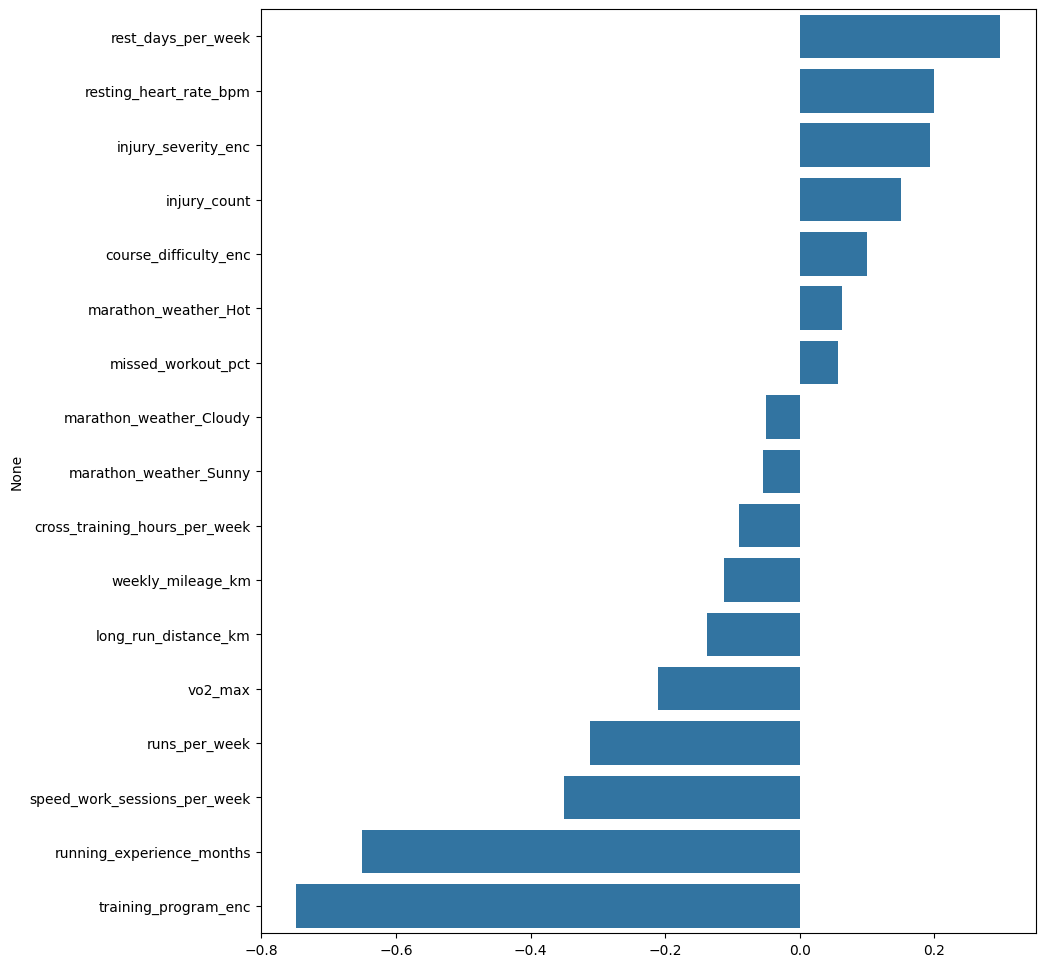

In [155]:
correlations = df_experminet.corr()['actual_finish_time_minutes'].sort_values(ascending=False)
correlations = correlations.drop('actual_finish_time_minutes')
plt.figure(figsize=(10, 12))
sns.barplot(x=correlations.values, y=correlations.index)

In [166]:
df_experminet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78011 entries, 0 to 79999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   running_experience_months      78011 non-null  int64  
 1   weekly_mileage_km              78011 non-null  float64
 2   runs_per_week                  78011 non-null  int64  
 3   long_run_distance_km           78011 non-null  float64
 4   speed_work_sessions_per_week   78011 non-null  int64  
 5   rest_days_per_week             78011 non-null  int64  
 6   cross_training_hours_per_week  78011 non-null  float64
 7   resting_heart_rate_bpm         78011 non-null  int64  
 8   vo2_max                        78011 non-null  float64
 9   injury_count                   78011 non-null  int64  
 10  missed_workout_pct             78011 non-null  int64  
 11  actual_finish_time_minutes     78011 non-null  float64
 12  training_program_enc           78011 non-null  int6

In [158]:
X_exp = df_experminet.drop(columns=['actual_finish_time_minutes'])
y_exp = df_experminet['actual_finish_time_minutes']

In [159]:
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)

In [160]:
# Train the model
model = LinearRegression()
model.fit(X_train_exp, y_train_exp)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [161]:
y_pred_exp = model.predict(X_test_exp)

In [162]:
print(f"Baseline R2 Score: {r2_score(y_test_exp, y_pred_exp):.4f}")
print(f"Baseline MAE: {mean_absolute_error(y_test_exp, y_pred_exp):.2f} minutes")

Baseline R2 Score: 0.6311
Baseline MAE: 16.22 minutes


 ## Age between 45-54

In [101]:
df_age_group = df_final[(df_final['age'] >= 45) & (df_final['age'] <= 54)].copy()

In [102]:
len(df_age_group)

16173

In [103]:
X_sub = df_age_group.drop(columns=['actual_finish_time_minutes'])
y_sub = df_age_group['actual_finish_time_minutes']

In [105]:
model_sub = LinearRegression()
model_sub.fit(X_train_s, y_train_s)

y_pred_s = model_sub.predict(X_test_s)

In [106]:
print(f" 45-54 age Baseline R2 Score: {r2_score(y_test_s, y_pred_s):.4f}")
print(f" 45-54 age Baseline MAE: {mean_absolute_error(y_test_s, y_pred_s):.2f} minutes")

 45-54 age Baseline R2 Score: 0.6311
 45-54 age Baseline MAE: 16.41 minutes


## DNF Analysis

In [175]:
# DNF - Did Not Finish
dnf_group = df[df['actual_finish_time_minutes'].isnull()]

# Finishers
finisher_group = df[df['actual_finish_time_minutes'].notnull()]


print("--- DNF Group Avg ---")
print(dnf_group[['age', 'bmi', 'injury_count', 'training_adherence_pct']].mean())

print("\n--- Finishers Group Avg ---")
print(finisher_group[['age', 'bmi', 'injury_count', 'training_adherence_pct']].mean())

print("\nDNF Group Injury:")
print(dnf_group['injury_severity'].value_counts(normalize=True))

--- DNF Group Avg ---
age                       43.889894
bmi                       22.786677
injury_count               1.122172
training_adherence_pct    79.620412
dtype: float64

--- Finishers Group Avg ---
age                       41.478458
bmi                       22.781854
injury_count               0.537270
training_adherence_pct    80.405597
dtype: float64

DNF Group Injury:
injury_severity
Moderate    0.375000
Severe      0.313492
Minor       0.311508
Name: proportion, dtype: float64


## XGB

In [168]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)

In [187]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

In [188]:
model.fit(X_train_xgb, y_train_xgb)
y_pred_xgb = model.predict(X_test_xgb)

In [189]:
print(f"XGB R2 Score: {r2_score(y_test_xgb, y_pred_xgb)}")

XGB R2 Score: 0.614981973828738


# Feature Engineering

In [190]:
df_new_features = df_experminet.copy()

In [192]:
df_new_features['running_maturity'] = df_new_features['vo2_max'] * df_new_features['running_experience_months']

In [193]:
df_new_features['avg_run_dist'] = df_new_features['weekly_mileage_km'] / df_new_features['runs_per_week']

In [ ]:
df_new_features['realized_mileage'] = df_new_features['weekly_mileage_km'] * (df_new_features['training_adherence_pct'] / 100)

In [195]:
print(df_new_features[['vo2_max', 'running_experience_months', 'running_maturity']].corr())

                            vo2_max  running_experience_months  \
vo2_max                    1.000000                   0.159623   
running_experience_months  0.159623                   1.000000   
running_maturity           0.291769                   0.980972   

                           running_maturity  
vo2_max                            0.291769  
running_experience_months          0.980972  
running_maturity                   1.000000  


In [211]:
print(df_new_features[['avg_run_dist', 'weekly_mileage_km', 'runs_per_week']].corr())

                   avg_run_dist  weekly_mileage_km  runs_per_week
avg_run_dist           1.000000           0.915677      -0.285565
weekly_mileage_km      0.915677           1.000000       0.060002
runs_per_week         -0.285565           0.060002       1.000000


In [214]:
df_new_features = df_new_features.drop(columns=["weekly_mileage_km", "running_experience_months"])

## Testing

In [217]:
X_new = df_new_features.drop(columns=['actual_finish_time_minutes'])
y_new = df_new_features['actual_finish_time_minutes']

In [218]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [207]:
model.fit(X_train_new, y_train_new)
y_pred_test_new = model.predict(X_test_new)

In [208]:
print(f"New Feat R2 Score: {r2_score(y_test_new, y_pred_test_new)}")

New Feat R2 Score: 0.6156200683242872


In [209]:
importance = model.feature_importances_

In [210]:
importance

array([0.38935205, 0.01725182, 0.01177515, 0.01601181, 0.01357661,
       0.        , 0.01688866, 0.03235654, 0.01984386, 0.03701326,
       0.02011058, 0.        , 0.04458907, 0.22443156, 0.03880665,
       0.03375071, 0.03955309, 0.02343551, 0.02125315], dtype=float32)

## Voting Regressor

In [215]:
model_lr = LinearRegression()
model_xgb = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)

In [216]:
voting_model = VotingRegressor(
    estimators=[
        ('lr', model_lr),
        ('xgb', model_xgb)
    ]
)

In [219]:
voting_model.fit(X_train_new, y_train_new)

,estimators,"[('lr', ...), ('xgb', ...)]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,objective,'reg:squarederror'
,base_score,None


In [220]:
y_pred_voting = voting_model.fit(X_train_new, y_train_new).predict(X_test_new)
print(f"Voting Regressor R2 Score: {r2_score(y_test_new, y_pred_voting)}")

Voting Regressor R2 Score: 0.6359928942971158


In [222]:
residuals = y_test_new - y_pred_voting

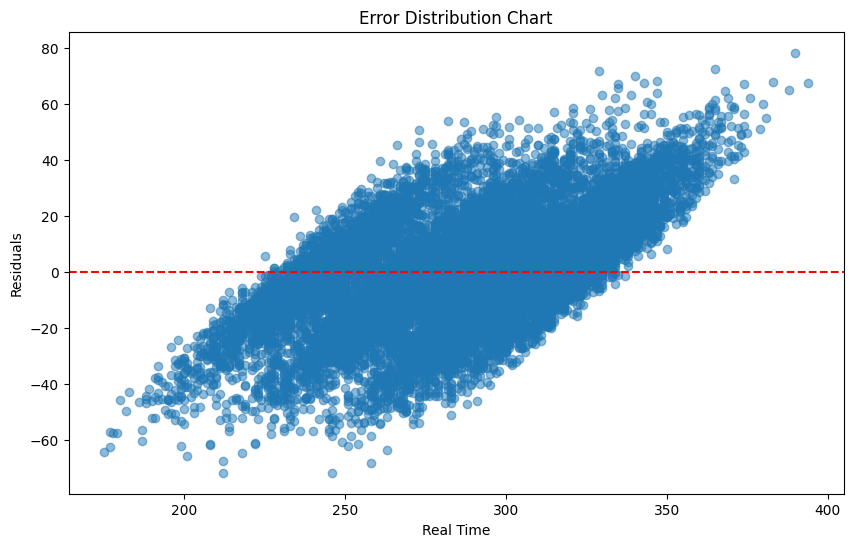

In [225]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Real Time')
plt.ylabel('Residuals')
plt.title('Error Distribution Chart')
plt.show()

In [232]:
voting_model.fit(X_train_final, y_train_new)

,estimators,"[('lr', ...), ('xgb', ...)]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,objective,'reg:squarederror'
,base_score,None


In [233]:
y_pred_final = voting_model.fit(X_train_final, y_train_final).predict(X_test_final)
print(f"Voting Regressor R2 Score: {r2_score(y_test_final, y_pred_final)}")

Voting Regressor R2 Score: 0.6366691563008783


## deep learning

In [221]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train_new, y_train_new)
print(f"MLP R2 Score: {mlp.score(X_test_new, y_test_new)}")

MLP R2 Score: 0.5582964585878325
